# Week 2 Assignment 
## Build an end-to-end ML pipeline on sales/price data.

In [3]:
%pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Cell 1 - imports & global config
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style="whitegrid")

In [6]:
# Cell 2 - load CSV and quick EDA
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("shape:", df.shape)
display(df.head())
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

Missing values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [7]:
# Cell 3 - create date and aggregate to monthly totals (overall)
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('date')

monthly = df.groupby('date', as_index=False).agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean'
})
monthly = monthly.sort_values('date').reset_index(drop=True)
display(monthly.head())

,date,Estimated_Deliveries,Production_Units,Avg_Price_USD
0,2015-01-01,183180,195793,84502.4970
1,2015-02-01,165053,176119,81745.5695
2,2015-03-01,184567,200151,86221.2895
3,2015-04-01,225623,241706,83446.1640
4,2015-05-01,184264,198205,85632.1110


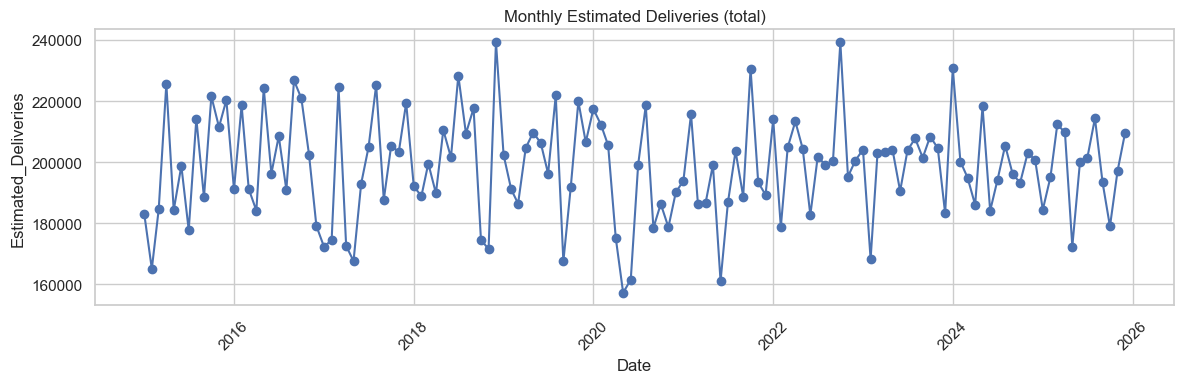

In [8]:
# Cell 4 - plot series
plt.figure(figsize=(12,4))
plt.plot(monthly['date'], monthly['Estimated_Deliveries'], marker='o')
plt.title("Monthly Estimated Deliveries (total)")
plt.xlabel("Date"); plt.ylabel("Estimated_Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Cell 5 - add lag and rolling features
monthly['lag1'] = monthly['Estimated_Deliveries'].shift(1)
monthly['lag2'] = monthly['Estimated_Deliveries'].shift(2)
monthly['lag3'] = monthly['Estimated_Deliveries'].shift(3)
monthly['rolling_mean_3'] = monthly['Estimated_Deliveries'].shift(1).rolling(3).mean()
monthly = monthly.dropna().reset_index(drop=True)
display(monthly.tail())

,date,Estimated_Deliveries,Production_Units,Avg_Price_USD,lag1,lag2,lag3,rolling_mean_3
124,2025-08-01,214357,225466,85621.9175,201390.0,199951.0,172377.0,191239.333333
125,2025-09-01,193337,205573,88418.6790,214357.0,201390.0,199951.0,205232.666667
126,2025-10-01,178964,190202,83172.4925,193337.0,214357.0,201390.0,203028.000000
127,2025-11-01,197146,213112,85915.3380,178964.0,193337.0,214357.0,195552.666667
128,2025-12-01,209391,225981,78212.7840,197146.0,178964.0,193337.0,189815.666667


In [10]:
# Cell 6 - time-aware split (last 12 months as test)
test_months = 12
train = monthly.iloc[:-test_months]
test  = monthly.iloc[-test_months:]

X_train = train[['lag1','lag2','lag3','rolling_mean_3','Production_Units','Avg_Price_USD']]
y_train = train['Estimated_Deliveries']
X_test  = test[['lag1','lag2','lag3','rolling_mean_3','Production_Units','Avg_Price_USD']]
y_test  = test['Estimated_Deliveries']

print("train:", X_train.shape, "test:", X_test.shape)

train: (117, 6) test: (12, 6)


In [11]:
# Cell 7 - baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr_train = lr.predict(X_train)
pred_lr_test  = lr.predict(X_test)

In [12]:
# Cell 8 - RandomForest baseline
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf_train = rf.predict(X_train)
pred_rf_test  = rf.predict(X_test)

In [14]:
# Cell 9 - evaluation
def print_metrics(y_true, y_pred, tag=""):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{tag} MAE: {mae:.1f}, RMSE: {rmse:.1f}, R2: {r2:.3f}")

print("Linear Regression — train")
print_metrics(y_train, pred_lr_train, "LR-train")
print("Linear Regression — test")
print_metrics(y_test, pred_lr_test, "LR-test")

print("\nRandom Forest — train")
print_metrics(y_train, pred_rf_train, "RF-train")
print("Random Forest — test")
print_metrics(y_test, pred_rf_test, "RF-test")

Linear Regression — train
LR-train MAE: 1371.0, RMSE: 1714.2, R2: 0.990
Linear Regression — test
LR-test MAE: 1873.7, RMSE: 2197.1, R2: 0.971

Random Forest — train
RF-train MAE: 714.9, RMSE: 911.3, R2: 0.997
Random Forest — test
RF-test MAE: 2119.2, RMSE: 2717.5, R2: 0.955


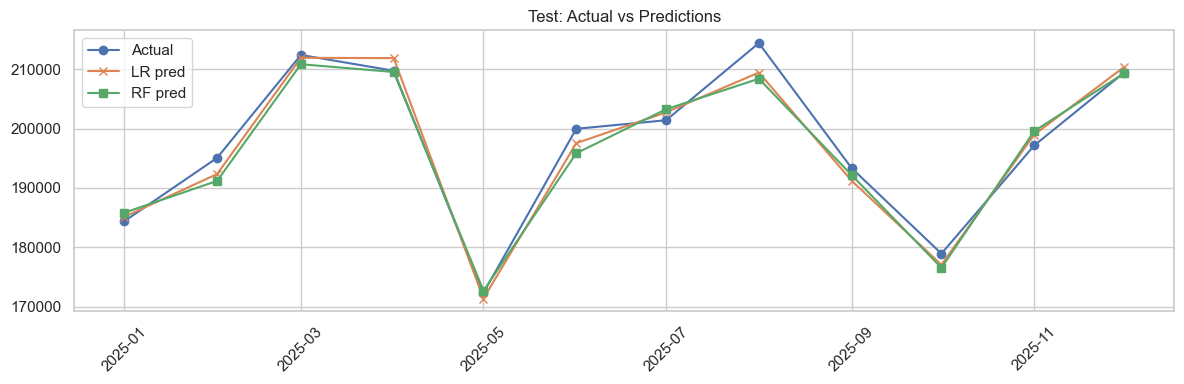

In [15]:
# Cell 10 - plot test predictions
plt.figure(figsize=(12,4))
dates_test = test['date']
plt.plot(dates_test, y_test.values, label='Actual', marker='o')
plt.plot(dates_test, pred_lr_test, label='LR pred', marker='x')
plt.plot(dates_test, pred_rf_test, label='RF pred', marker='s')
plt.xticks(rotation=45); plt.legend(); plt.title("Test: Actual vs Predictions"); plt.tight_layout(); plt.show()

In [16]:
# Cell 11 - choose best by MAE and save
mae_lr = mean_absolute_error(y_test, pred_lr_test)
mae_rf = mean_absolute_error(y_test, pred_rf_test)
best = rf if mae_rf < mae_lr else lr
best_name = 'random_forest' if mae_rf < mae_lr else 'linear_regression'
joblib.dump(best, f"best_model_{best_name}.pkl")
print("Saved model:", f"best_model_{best_name}.pkl")

Saved model: best_model_linear_regression.pkl


I aggregated to monthly totals to keep the first pipeline simple.
Lags + rolling mean capture short-term autocorrelation.
Time split prevents leakage; last 12 months used as test.
Next steps: per-Region/Model models, hyperparameter search, or use Prophet/SARIMAX for forecasting.